# RECEIPT DETECTOR
This notebook is present for data and model exploration.

The goal is to extract the items and summaries from a reciept.

Short term plan: Use pre-trained model and collect the data.

Long term plan: Experimenting with base models and train it using collected data.

## Data Exploration

In [95]:
import matplotlib.pyplot as plt
import json
from PIL import ImageDraw
import numpy as np
import re
import pandas as pd

### Importing Data from Huggingface naver-clova-ix/cord-v2

In [96]:
from datasets import load_dataset

dataset_name = "naver-clova-ix/cord-v2"
dataset = load_dataset(dataset_name, cache_dir='./data/CORD')

In [97]:
ds_train = dataset['train']

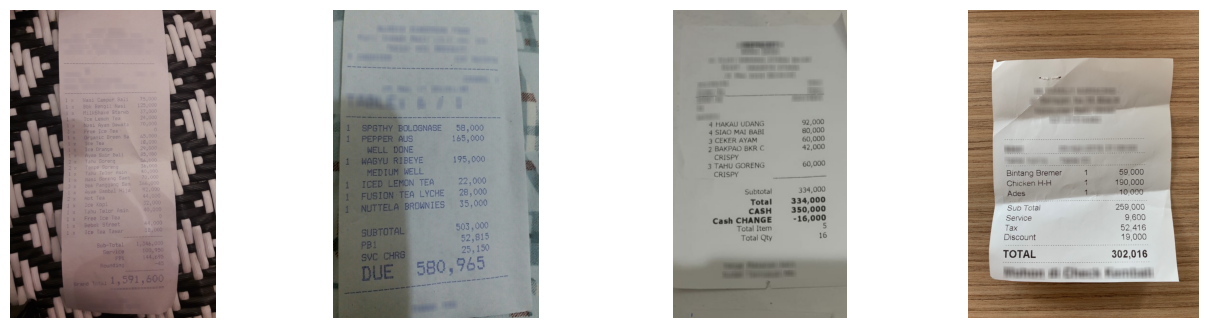

In [98]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for i, image in enumerate(ds_train[:4]['image']):
    axs[i].imshow(image)
    axs[i].set_axis_off()

plt.show()

In [99]:
for i, label in enumerate(ds_train[:4]['ground_truth']):
    print(f"[{i}] GT: {label}")

[0] GT: {"gt_parse": {"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1 x", "price": "70,000"}, {"nm": "Free Ice Tea", "cnt": "3 x", "price": "0"}, {"nm": "Organic Green Sa", "cnt": "1 x", "price": "65,000"}, {"nm": "Ice Tea", "cnt": "1 x", "price": "18,000"}, {"nm": "Ice Orange", "cnt": "1 x", "price": "29,000"}, {"nm": "Ayam Suir Bali", "cnt": "1 x", "price": "85,000"}, {"nm": "Tahu Goreng", "cnt": "2 x", "price": "36,000"}, {"nm": "Tempe Goreng", "cnt": "2 x", "price": "36,000"}, {"nm": "Tahu Telor Asin", "cnt": "1 x", "price": "40,000."}, {"nm": "Nasi Goreng Samb", "cnt": "1 x", "price": "70,000"}, {"nm": "Bbk Panggang Sam", "cnt": "3 x", "price": "366,000"}, {"nm": "Ayam Sambal Hija", "cnt": "1 x", "price": "92,000"}, {"nm": "Hot Tea", "cnt": "2 x"

In [100]:
print(type(ds_train[0]["ground_truth"]))

<class 'str'>


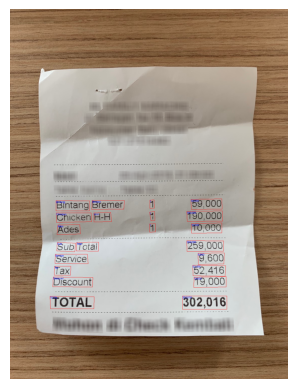

In [101]:
sample = ds_train[3]
image = sample['image'].convert("RGB")
label = json.loads(sample['ground_truth'])
draw = ImageDraw.Draw(image)

for line in label['valid_line']:
    for word in line['words']:
        quad = word['quad']
        
        # extract coordinates
        points = [(quad['x1'], quad['y1']), (quad['x2'], quad['y2']),
                  (quad['x3'], quad['y3']), (quad['x4'], quad['y4'])]
        draw.polygon(points, outline="red")
        draw.text((quad['x1'], quad['y1']), word['text'], fill="blue")

plt.imshow(image)
plt.axis('off')
plt.show()


### Pre-processing
Using opencv to enhance the input, so the model can recognize the texts better.

In [102]:
import cv2

In [103]:
def resize(img:np.ndarray, scale:int=3) -> np.ndarray:
    """
    Resize an image by a given scale factor using bicubic interpolation.

    Args:
        img (np.ndarray): Input image (grayscale or color).
        scale (float, optional): Scaling factor (e.g., 2.0 = double size). Default is 3.0.

    Returns:
        np.ndarray: Resized image.
    """
    return cv2.resize(np.array(img), None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

In [104]:
def gray(img:np.ndarray) -> np.ndarray:
    """
    Convert an image to grayscale.

    Args:
        img (np.ndarray): Input image in BGR (color) or grayscale.

    Returns:
        np.ndarray: Grayscale image.
    """
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [105]:
def denoise(
    img: np.ndarray,
    h: int = 3,
    kernel_size: tuple = (2, 2)
) -> np.ndarray:
    """
    Apply denoising and morphological closing to clean up receipt images for OCR.

    Steps:
    1. Non-local means denoising to reduce background noise while preserving text edges.
    2. Morphological closing (dilation → erosion) to fill small gaps inside text characters.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.
    h : int, default=3
        Filter strength for `cv2.fastNlMeansDenoising`.
        - Lower values preserve more details but remove less noise.
        - Higher values remove more noise but may blur text.
    kernel_size : tuple of int, default=(2, 2)
        Size of the structuring element for morphological closing.
        - Larger values fill bigger gaps but may cause letters to merge.
        - Smaller values keep letters separated but may leave gaps.

    Returns
    -------
    np.ndarray
        Denoised and morphologically processed image, ready for thresholding or OCR.
    """
    # Step 1: Reduce noise while preserving text
    denoised = cv2.fastNlMeansDenoising(img, h=h)

    # Step 2: Define kernel for morphological closing
    kernel = np.ones(kernel_size, np.uint8)

    # Step 3: Apply morphological closing
    return cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)

In [106]:
import cv2
import numpy as np

def threshold(img: np.ndarray, thresh_val: int = 0, max_val: int = 255, method: str = "otsu") -> np.ndarray:
    """
    Apply thresholding to binarize the image for OCR preprocessing.

    Parameters
    ----------
    img : np.ndarray
        Input image, can be grayscale or color.
    thresh_val : int, default=0
        Threshold cutoff value (0-255). Determines the split point between black and white.
        - Low values (e.g., 50): More pixels turn white → keeps faint text but also includes noise.
        - High values (e.g., 200): More pixels turn black → good for dark text but may lose faint ink.
        - Middle values (120-150): Often balanced, but less robust under uneven lighting.
    max_val : int, default=255
        Value assigned to pixels above the threshold (usually white).
    method : str, default="otsu"
        Thresholding method:
        - "binary": Fixed global threshold using `thresh_val`.
        - "otsu": Automatic threshold selection using Otsu's method (works best for varying brightness).
        - "adaptive": Adaptive thresholding for uneven lighting.

    Returns
    -------
    np.ndarray
        Thresholded binary image (black and white).

    Notes
    -----
    - `thresh_val` is the cutoff that decides whether a pixel is black or white.
    - Too low → background noise may stay.
    - Too high → faint text may disappear.
    - Otsu's method auto-selects `thresh_val` by analyzing image histogram.
    - Adaptive thresholding can handle folds, shadows, or uneven receipt lighting.
    """
    if len(img.shape) == 3:  # convert to grayscale if color
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    if method == "binary":
        _, binary = cv2.threshold(gray, thresh_val, max_val, cv2.THRESH_BINARY)
        return binary
    elif method == "adaptive":
        return cv2.adaptiveThreshold(
            gray, max_val, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 11, 2
        )
    else:  # default to Otsu
        _, binary = cv2.threshold(gray, 0, max_val, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary

In [107]:
def sharpen(img:np.ndarray, kernel_size=(5,5), sigma=1.0, amount=1.5) -> np.ndarray:
    """
    Increase sharpness using unsharp masking.

    Args:
        img (np.ndarray): Input image.
        kernel_size (tuple): Size of Gaussian blur kernel.
        sigma (float): Standard deviation for Gaussian blur.
        amount (float): Sharpening amount (1.0 = normal, >1 stronger).

    Returns:
        np.ndarray: Sharpened image.
    """

    blurred = cv2.GaussianBlur(img, kernel_size, sigma)
    return cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

In [108]:
def contrast(img: np.ndarray, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Enhance local image contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization).

    If the input is grayscale, CLAHE is applied directly.
    If the input is a color image, CLAHE is applied only to the luminance (Y) channel in YCrCb space
    to preserve natural colors while improving brightness and contrast.

    Parameters
    ----------
    img : np.ndarray
        Input image (grayscale or color).
    clip_limit : float, default=2.0
        Threshold for contrast limiting. Higher values give more contrast.
    tile_grid_size : tuple(int, int), default=(8, 8)
        Size of the grid for histogram equalization. Smaller tiles → more localized contrast.

    Returns
    -------
    np.ndarray
        Image with enhanced contrast (same number of channels as input).
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    if len(img.shape) == 2:  # Grayscale
        return clahe.apply(img)

    # Color image → apply CLAHE to luminance channel
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    y, cr, cb = cv2.split(ycrcb)

    y_clahe = clahe.apply(y)

    merged = cv2.merge((y_clahe, cr, cb))
    return cv2.cvtColor(merged, cv2.COLOR_YCrCb2BGR)


In [109]:
def invert(img: np.ndarray) -> np.ndarray:
    """
    Invert the pixel values of an image (bitwise NOT).
    
    This operation flips black ↔ white (and generally inverts all colors):
      - A pixel value `p` becomes `255 - p` for 8-bit images.
      - Useful in OCR pipelines if text/background polarity is wrong 
        (e.g., white text on black background instead of black text on white).
    
    Parameters
    ----------
    img : np.ndarray
        Input image (grayscale or color, dtype=uint8).
    
    Returns
    -------
    np.ndarray
        Inverted image of the same shape and type.
    """
    return cv2.bitwise_not(img)


In [110]:
from typing import List, Callable

def process_img(img: np.ndarray, pipeline: List[Callable]) -> np.ndarray:
    """
    Apply a sequence of preprocessing functions to an image.

    This utility function allows you to chain multiple image processing
    operations (e.g., resize → grayscale → denoise → threshold) into
    a single, reusable pipeline. Each function in `processors` must take
    an image (np.ndarray) as input and return the transformed image.

    Parameters
    ----------
    img : np.ndarray
        The input image to be processed.
    processors : List[Callable]
        A list of functions, each with the signature `func(img: np.ndarray) -> np.ndarray`.
        They will be applied sequentially in the order provided.

    Returns
    -------
    np.ndarray
        The processed image after all transformations have been applied.

    Example
    -------
    >>> pipeline = [resize, gray, denoise, threshold]
    >>> result = process_img(img, pipeline)
    """
    for func in pipeline:
        img = func(img)

    return img

In [111]:
def show_images(images: List[np.ndarray], titles: List[str] = None, cmap="gray", figsize=(15, 5)):
    """
    Display multiple images side by side using matplotlib.

    Parameters
    ----------
    images : List[np.ndarray]
        List of images (NumPy arrays) to display.
    titles : List[str], optional
        Titles for each image. Must be the same length as `images`.
    cmap : str, optional
        Colormap to use (default: "gray").
    figsize : tuple, optional
        Size of the figure in inches.

    Example
    -------
    >>> show_images([img, gray_img, thresh_img],
    ...             ["Original", "Grayscale", "Thresholded"])
    """
    n = len(images)
    fig, axs = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axs = [axs]  # keep iterable

    for i, img in enumerate(images):
        axs[i].imshow(img, cmap=cmap if img.ndim == 2 else None)
        axs[i].axis("off")
        if titles and i < len(titles):
            axs[i].set_title(titles[i])

    plt.show()

In [112]:
def show_images(
    images: List[np.ndarray],
    titles: List[str] = None,
    cmap: str = "gray",
    figsize: tuple = (15, 8),
    nrows: int = 1,
    ncols: int = None
):
    """
    Display multiple images in a grid using matplotlib.

    Parameters
    ----------
    images : List[np.ndarray]
        List of images (NumPy arrays) to display.
    titles : List[str], optional
        Titles for each image. Must match the length of `images`.
    cmap : str, optional
        Colormap for grayscale images (default: "gray").
    figsize : tuple, optional
        Size of the figure in inches (width, height).
    nrows : int, optional
        Number of rows in the grid (default: 1).
    ncols : int, optional
        Number of columns in the grid. If None, computed as ceil(len(images) / nrows).

    Example
    -------
    >>> show_images(
    ...     [img, gray_img, denoised_img, thresh_img],
    ...     ["Original", "Gray", "Denoised", "Thresholded"],
    ...     nrows=2, ncols=2
    ... )
    """
    n_images = len(images)
    if ncols is None:
        ncols = int(np.ceil(n_images / nrows))

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = np.array(axs).reshape(-1)  # flatten grid to 1D for easy indexing

    for i, img in enumerate(images):
        axs[i].imshow(img, cmap=cmap if img.ndim == 2 else None)
        axs[i].axis("off")
        if titles and i < len(titles):
            axs[i].set_title(titles[i])

    # Hide unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

In [113]:
def enhance_contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

##### Visualisation of each type of optimisation

In [114]:
img = np.array(ds_train[3]['image'])

In [115]:
resized = resize(img=img)

In [116]:
grayed = gray(img=img)

In [117]:
denoised = denoise(img=img)

In [118]:
thresh = threshold(img=img)

In [119]:
sharpened = sharpen(img=img)

In [120]:
contrasted = contrast(img=img)

In [121]:
inverted = invert(img=img)

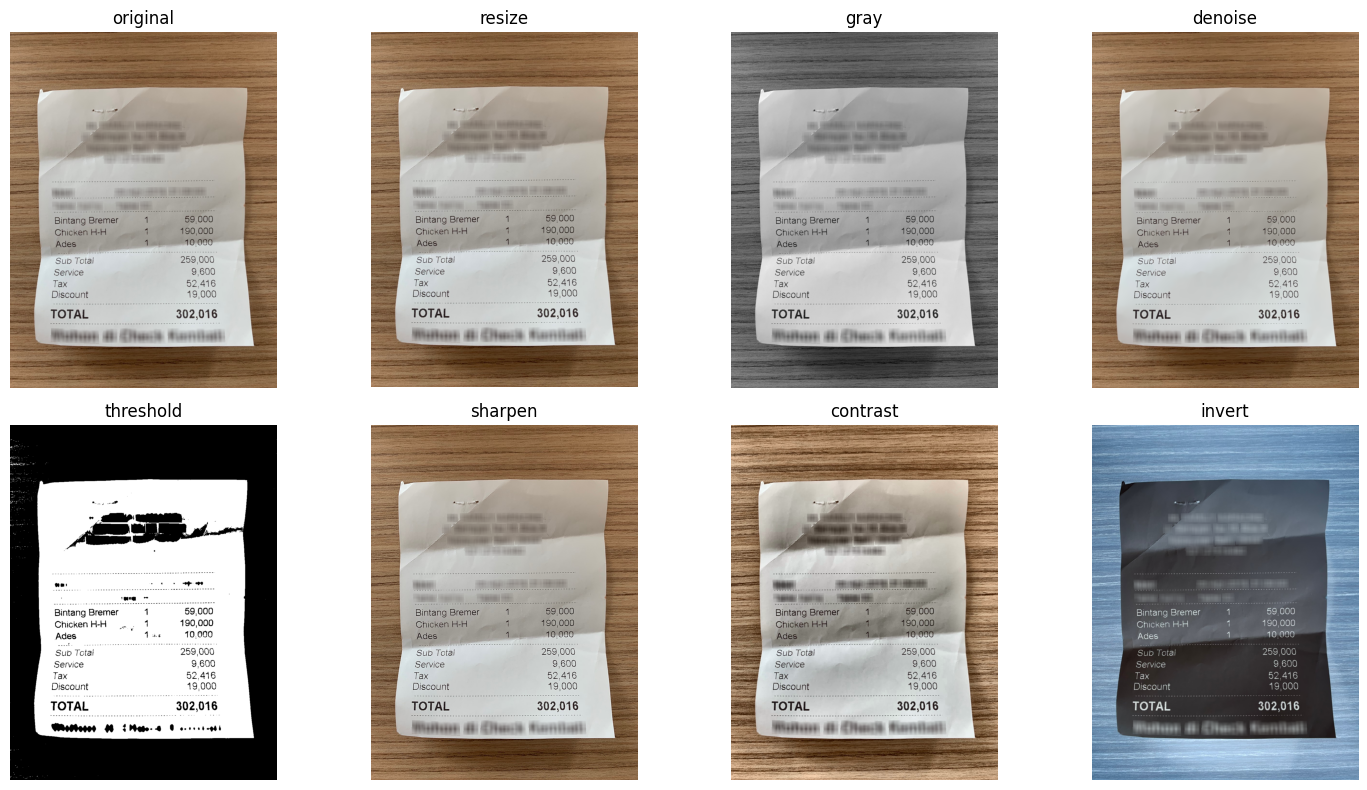

In [122]:
show_images(images=[img, resized, grayed, denoised, thresh, sharpened, contrasted, inverted],
            titles=['original', 'resize', 'gray', 'denoise', 'threshold', 'sharpen', 'contrast', 'invert'],
            nrows=2, ncols=4)

#### Pipeline

Series of image optimization

In [123]:
from functools import partial

pipeline1 = [
    partial(resize, scale=4),
    partial(sharpen, amount=2),
    gray,
    partial(denoise, h=2, kernel_size=(3,3)),
    partial(threshold, method='Adaptive'),
    partial(contrast, clip_limit=5)
]

pipeline2 = [
    partial(resize, scale=4),
    gray,
    partial(denoise, h=3, kernel_size=(3,3)),
    partial(threshold, method='Otsu'),
    partial(sharpen, amount=1.5)
]

pipeline3 = [
    partial(resize, scale=3),
    partial(contrast, clip_limit=3),
    gray,
    partial(denoise, h=2, kernel_size=(3,3)),
    partial(threshold, method='Adaptive')
]

pipeline4 = [
    partial(resize, scale=4),
    gray,
    partial(contrast, clip_limit=3, tile_grid_size=(8,8)),
    partial(denoise, h=2, kernel_size=(3,3)),
    partial(threshold, method="Adaptive"),
    partial(sharpen, amount=1.2)
]

pipeline5 = [
    partial(resize, scale=3),
    gray,
    partial(denoise, h=3, kernel_size=(3,3)),
    partial(threshold, method="Otsu"),
    partial(sharpen, amount=1.5)
]

pipeline6 = [
    partial(resize, scale=3),                           # enlarge text
    gray,                                               # convert to grayscale
    partial(cv2.bilateralFilter, d=9, sigmaColor=75, sigmaSpace=75),  # denoise but preserve edges
    partial(cv2.equalizeHist),                          # normalize brightness/contrast
    partial(cv2.adaptiveThreshold, maxValue=255,
            adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            thresholdType=cv2.THRESH_BINARY, blockSize=21, C=10),     # local threshold for folds
    partial(cv2.morphologyEx, op=cv2.MORPH_OPEN, kernel=np.ones((2,2), np.uint8))  # clean noise
]

pipeline7 = [
    partial(resize, scale=3),                           # enlarge text
    gray,                                               # grayscale
    partial(cv2.bilateralFilter, d=9, sigmaColor=75, sigmaSpace=75),  # denoise but preserve edges
    partial(cv2.equalizeHist),                          # normalize brightness/contrast
    partial(cv2.adaptiveThreshold, maxValue=255,
            adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            thresholdType=cv2.THRESH_BINARY, blockSize=21, C=10),     # adaptive binarization
    partial(cv2.morphologyEx, op=cv2.MORPH_OPEN, kernel=np.ones((2,2), np.uint8)),  # clean small noise
    partial(sharpen, amount=1.2)  
]

pipeline8 = [
    partial(resize, scale=3),                           # enlarge text
    gray,                                               # grayscale
    partial(cv2.bilateralFilter, d=9, sigmaColor=75, sigmaSpace=75),  # denoise
    partial(cv2.equalizeHist),                          # normalize contrast
    partial(cv2.adaptiveThreshold, maxValue=255,
            adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            thresholdType=cv2.THRESH_BINARY, blockSize=15, C=8),     # smaller blocks than before
    partial(cv2.morphologyEx, op=cv2.MORPH_OPEN, kernel=np.ones((2,2), np.uint8)),  # clean specks
    partial(sharpen, amount=1.3)                        # make characters pop
]

In [124]:
pipelines = {
    'Pipeline 1': pipeline1,
    'Pipeline 2': pipeline2,
    'Pipeline 3': pipeline3,
    'Pipeline 4': pipeline4,
    'Pipeline 5': pipeline5,
    'Pipeline 6': pipeline6,
    'Pipeline 7': pipeline7,
    'Pipeline 8': pipeline8
}

In [125]:
input = {
    'img': ds_train[3]['image'],
    'lines': [
        'Bintang Bremer 1 59,000',
        'Chicken H-H 1 190,000',
        'Ades 1 10,000',
        'Sub Total 259,000',
        'Service 9,600',
        'Tax 52,416',
        'Discount 19,000',
        'TOTAL 302,016'
    ]
}

## OCR
for simplicity, pre-trained model will be used instead of training a new model. In the future, new model might be developed

### Evaluation Method

#### Method 1: Compare the key details

In [126]:
from rapidfuzz import fuzz

def evaluate_details(gt_details, ocr_details, price_tol=1e-3):
    total = 0
    correct = 0
    details = []

    for gt, ocr in zip(gt_details, ocr_details):  # assumes same length/order
        total += 1
        cat_match = gt['category'] == ocr['category']
        
        item_score = fuzz.ratio(gt['info']['item'], ocr['info']['item'])
        qty_match = gt['info'].get('qty') == ocr['info'].get('qty')

        price_match = False
        
        if gt['category'] == 'item' and ocr['category'] == 'item':
            gt_price = gt['info']['price']['numeric']
            ocr_price = ocr['info']['price']['numeric']
            price_match = abs(gt_price - ocr_price) <= price_tol
        elif gt['category'] == 'summary' and ocr['category'] == 'summary':
            gt_price = gt['info']['price']['numeric']
            ocr_price = ocr['info']['price']['numeric']
            price_match = abs(gt_price - ocr_price) <= price_tol

        record_correct = cat_match and item_score > 90 and qty_match and price_match
        if record_correct:
            correct += 1

        details.append({
            "gt": gt,
            "ocr": ocr,
            "item_score": item_score,
            "qty_match": qty_match,
            "price_match": price_match,
            "overall": record_correct
        })

    return correct / total if total > 0 else 0

#### Method 2: Match sentences

In [127]:
from rapidfuzz.distance import Levenshtein

def evaluate_against_ground_truth_levenshtein(ocr_lines, actual_lines):
    # Join lines with newline, then compute edit distance
    ocr_text = "\n".join(ocr_lines).lower().strip()
    actual_text = "\n".join(actual_lines).lower().strip()

    dist = Levenshtein.normalized_similarity(ocr_text, actual_text)
    return dist  # value between 0.0 and 1.0

### First Candidate: Tesseract

In [128]:
TESSERACT_SAVE_TO_FILE=False

In [129]:
import pytesseract

def run_ocr(img, psm=6, lang="eng"):
    cfg = f"--oem 3 --psm {psm} -c preserve_interword_spaces=1 -c user_defined_dpi=300"
    # Optional whitelist if you want to be stricter:
    # cfg += " -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz,.-"
    df = pytesseract.image_to_data(img, output_type=pytesseract.Output.DATAFRAME, config=cfg, lang=lang)
    df = df[df.conf != -1]  # drop empty rows
    return df, (df.conf.astype(float).mean() if len(df) else 0.0)

In [130]:
def best_psm(img, psms=(4,6,11,12), lang="eng"):
    scores = {}
    for p in psms:
        df, score = run_ocr(img, psm=p, lang=lang)
        scores[p] = (score, df)
    best = max(scores.items(), key=lambda kv: kv[1][0])
    best_psm_val, (best_score, best_df) = best
    return best_psm_val, best_score, best_df

In [131]:
def try_psms(img, psms=(4, 6, 11, 12), lang="eng"):
    results = []
    for p in psms:
        print(f'[try_psms] Using psm = {p}')

        df, score = run_ocr(img, psm=p, lang=lang)
        results.append({
            "psm": p,
            "score": score,
            "df": df
        })

    # sort results from best to worst by score
    results.sort(key=lambda x: x["score"], reverse=True)

    return results

In [132]:
def try_pipeline(img, pipelines, skip=[], lang="eng+ind", skip_combo=[]):
    out = {}
    for name, pipe in pipelines.items():
        if name in skip:
            continue

        psms = [4,6,11,12]

        for combo in skip_combo:
            if name == combo[0] and combo[1] in psms:
                psms.remove(combo[1])

        print(f'[try_pipeline] Using: {name}')

        proc = img
        for f in pipe: proc = f(proc)

        results = try_psms(img=proc, psms=psms, lang=lang)
        for res in results:
            out[f'{name}-{res['psm']}'] = res
    
    return out

In [133]:
def group_by_line(data):
    # Group by line
    lines = data.groupby(['block_num', 'par_num', 'line_num'])['text'].apply(lambda x: " ".join(x))
    
    # Reset index so it's easier to handle
    lines = lines.reset_index(drop=True)
    
    return lines

In [134]:
from rapidfuzz import process, fuzz
import re

LEXICON = ["Subtotal", "Total", "Discount", "Service", "Tax"]

def correct_text(ocr_lines, lexicon=LEXICON):
    corrected = []
    for line in ocr_lines:
        words = line.split()
        fixed_words = []
        for w in words:
            # If word is mostly digits, skip to numeric fix
            if re.fullmatch(r"[0-9,\.]+", w):
                fixed_words.append(w)
                continue

            # Try fuzzy matching against lexicon
            match, score, _ = process.extractOne(w, lexicon, scorer=fuzz.ratio)
            if score > 80:
                fixed_words.append(match)  # replace with lexicon word
            else:
                fixed_words.append(w)
        corrected.append(" ".join(fixed_words))
    return corrected

In [135]:
import time


def eval_pipeline_result(out=None, confidence_threshold=(30,40,50,70), ground_truth=[], evaluator=evaluate_against_ground_truth_levenshtein, with_correction=False):
    """
    Evaluate multiple OCR pipeline results and return the best pipeline with its result.
    
    Args:
        out (dict): mapping {pipeline_name: {"psm": int, "score": float, "df": DataFrame}}
        confidence_threshold (tuple): thresholds for filtering results by confidence.
    
    Returns:
        tuple: (best_name, best_res) where best_res is {"psm": int, "score": float, "df": DataFrame}
    """

    logFile = open(f'./out/tesseract/eval_pipeline_result-{time.time()}.txt', 'w')

    if not out:
        return None, None
    
    scores = []
        
    for name, res in out.items():
        psm = res["psm"]
        score = res["score"]
        df = res["df"]

        logFile.write('==============================================\n')
        logFile.write(f'Pipeline: {name}\n')
        logFile.write(f'PSM VAL: {psm}\n')
        logFile.write(f'Score: {score}\n')

        logFile.write("Raw OCR Data:\n")
        logFile.write(df.to_string() + '\n\n')

        base_data = df.dropna(subset=["text"])
        
        for t in confidence_threshold:
            filtered = base_data[base_data["conf"] > t]

            if filtered.empty:
                logFile.write(f"Confidence threshold {t}: No text passed filter.\n")
                continue

            lines = group_by_line(data=filtered)

            logFile.write('----------------------------\n')
            logFile.write(f'Name: {name}\n')
            logFile.write(f'Confidence threshold: {t}\n')
            logFile.write('----------------------------\n')
            logFile.write(f'Lines:\n{lines}\n\n')

            metric_score = evaluator(ocr_lines=lines, actual_lines=ground_truth)

            metric = {
                'name': name,
                'psm': psm,
                'conf_threshold': t,
                'score': metric_score
            }

            scores.append(metric)

            if with_correction:
                # corrected
                corrected = correct_text(ocr_lines=lines)

                logFile.write('----------------------------\n')
                logFile.write(f'Name: {name} Corrected\n')
                logFile.write(f'Confidence threshold: {t}\n')
                logFile.write('----------------------------\n')
                logFile.write(f'Lines:\n{corrected}\n\n')

                metric_score = evaluator(ocr_lines=lines, actual_lines=ground_truth)

                metric = {
                    'name': f'{name}-corrected',
                    'psm': psm,
                    'conf_threshold': t,
                    'score': metric_score
                }

                scores.append(metric)
    
    logFile.close()
    
    return scores            

In [136]:
# custom_config = r'--oem 3 --psm 6'
# data = pytesseract.image_to_data(processed, output_type=pytesseract.Output.DATAFRAME, config=custom_config)

out = try_pipeline(
    img=input['img'], 
    pipelines=pipelines, 
    skip=['Pipeline 6', 'Pipeline 4', 'Pipeline 3', 'Pipeline 7', 'Pipeline 8', 'Pipeline 2'],
    skip_combo=[('Pipeline 2', 4), ('Pipeline 1', 4), ('Pipeline 2', 12), ('Pipeline 6', 4), ('Pipeline 5', 4), ('Pipeline 5', 6), ('Pipeline 1', 11), ('Pipeline 1', 12)]
)

[try_pipeline] Using: Pipeline 1
[try_psms] Using psm = 6
[try_pipeline] Using: Pipeline 5
[try_psms] Using psm = 11
[try_psms] Using psm = 12


### Second Candidate: PaddleOCR

using model PP-OCRv3

pre-processing handled by Paddle

In [137]:
PADDLE_SAFE_TO_FILE=False

#### Sample Data

In [138]:
inputs = [
    {
        'name': 'input 1',
        'img': np.array(ds_train[3]['image']),
        'save_file': True,
        'lines': [
            'Bintang Bremer 1 59,000',
            'Chicken H-H 1 190,000',
            'Ades 1 10,000',
            'Sub Total 259,000',
            'Service 9,600',
            'Tax 52,416',
            'Discount 19,000',
            'TOTAL 302,016'
        ],
        'separated_lines': [
            ['Bintang Bremer', '1', '59,000'],
            ['Chicken H-H', '1', '190,000'],
            ['Ades', '1', '10,000'],
            ['Sub Total', '259,000'],
            ['Service', '9,600'],
            ['Tax', '52,416'],
            ['Discount', '19,000'],
            ['TOTAL', '302,016']
        ]
    },
    {
        'name': 'input 2',
        'img': np.array(ds_train[4]['image']),
        'save_file': True,
        'lines': [
            'BASO BIHUN 1 43.636 43.636',
            'TOTAL 43,636',
            'TAX 10.00 % 4.364',
            'GRAND TOTAL 48.000',
            'TUNAI 50.000',
            'KEMBALI 2.000'
        ],
        'separated_lines': [
            ['BASO BIHUN', '1', '43.636'],
            ['TOTAL', '43,636'],
            ['TAX 10.00 %', '4.364'],
            ['GRAND TOTAL', '48.000'],
            ['TUNAI', '50.000'],
            ['KEMBALI', '2.000']
        ]
    },
        {
        'name': 'input 3',
        'img': np.array(ds_train[5]['image']),
        'save_file': True,
        'lines': [
            '1 Lasagna 45,000',
            '1 Spaghetti ChickPesto 55,000',
            '1 BangBang Chick Wings 49,000',
            '1 Iced Cappuccino 33,000',
            '1 Gypsy Gelato Ice Tea 39,000',
            'SUBTOTAL 221,000',
            'Service 16,575',
            'PB1 23,750',
            'TOTAL 261,333',
            'Coupon 100,000',
            'BCA Card 161,333'
        ],
        'separated_lines': [
            ['1', 'Lasagna', '45,000'],
            ['1', 'Spaghetti ChickPesto', '55,000'],
            ['1', 'BangBang Chick Wings', '49,000'],
            ['1', 'Iced Cappuccino', '33,000'],
            ['1', 'Gypsy Gelato Ice Tea', '39,000'],
            ['SUBTOTAL', '221,000'],
            ['Service', '16,575'],
            ['PB1', '23,750'],
            ['TOTAL', '261,333'],
            ['Coupon', '100,000'],
            ['BCA Card', '161,333']
        ]
    }
]

#### Step 1: OCR Using Paddle

In [139]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    ocr_version="PP-OCRv3",
    use_textline_orientation=True,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    lang='en'
)

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/michaelyusaktarigan/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv3_mobile_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/michaelyusaktarigan/.paddlex/official_models/PP-OCRv3_mobile_det`.
Creating model: ('en_PP-OCRv3_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/michaelyusaktarigan/.paddlex/official_models/en_PP-OCRv3_mobile_rec`.


In [140]:
results = []

for input in inputs:
    res = ocr.predict(input['img'])

    results.append(res)

Resized image size (4096x2304) exceeds max_side_limit of 4000. Resizing to fit within limit.


In [141]:
res = results[0]

for r in res:
    r.print()

    if PADDLE_SAFE_TO_FILE:
        r.save_to_img("out/paddle/pre-test")
        r.save_to_json("out/paddle/pre-test")

{'res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': True}, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_orientation_classify': False, 'use_doc_unwarping': False}, 'angle': -1}, 'dt_polys': array([[[ 557,  765],
        ...,
        [ 557,  791]],

       ...,

       [[ 647, 1236],
        ...,
        [ 647, 1284]]], shape=(21, 4, 2), dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([0, ..., 0], shape=(21,)), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['1', '59.000', 'Bintang Bremer', 'Chicken H-H', '190.000', 'Ades', '1', '10.000', 'Sub Totai', '259,000', 'Service', '9,600', 'Tax', '52,416', 'Discount', '19,000', 'TOTAL', '302,016', 'H41', '10', 'MLlla'], 'rec_scores': arr

#### Step 2: Translate Result to Text Lines

##### Check if text horizontal

In [142]:
def is_horizontal(box, tolerance=0.7):
    """
    box: list of 4 points [(x1,y1), (x2,y2), (x3,y3), (x4,y4)]
    Returns True if box is mostly horizontal (width >> height).
    """

    dx = ((box[1][0] - box[0][0]) + (box[2][0] - box[3][0])) / 2
    dy = ((box[3][1] - box[0][1]) + (box[2][1] - box[1][1])) / 2

    dx, dy = abs(dx), abs(dy)

    # check orientation
    return dx >= dy * tolerance

* Option 1: Group by y

In [143]:
def group_by_line_paddle(res, y_tolerance=25, min_conf=0.7):
    """
    Group PaddleOCR results into lines using bounding box positions.

    Args:
        res (list[dict]): Output of ocr.predict()
        y_tolerance (int): vertical pixel tolerance for grouping into a line

    Returns:
        pd.Series: grouped text lines
    """
    items = []
    for page in res:  # in case of multipage
        polys = page["dt_polys"]       # list of quadrilaterals
        texts = page["rec_texts"]      # recognized text
        scores = page["rec_scores"]    # confidence scores

        for box, text, conf in zip(polys, texts, scores):
            if conf < min_conf:
                continue

            if not is_horizontal(box):
                continue

            if not text.strip():
                continue
            
            y_mean = np.mean([p[1] for p in box])  # average y
            x_mean = np.mean([p[0] for p in box])  # average x

            x_min = box[0][0]
            x_max = box[1][0]

            items.append((box, y_mean, x_mean, x_min, x_max, text, conf))

    # sort by y first, then x
    items = sorted(items, key=lambda x: (round(x[1] / y_tolerance), x[1]))

    lines = []
    current_y = None
    current_line = []

    for box, y_mean, x_mean, x_min, x_max, text, conf in items:
        group_y = round(y_mean / y_tolerance)
        if current_y is None:
            current_y = group_y

        if group_y != current_y:  # new line
            lines.append(current_line)
            current_line = [text]
            current_y = group_y
        else:
            current_line.append(text)

    if current_line:
        lines.append(current_line)

    return pd.Series(lines, name="text")

* Option 2: Check If Inline

Does a pre-sort (by y_min, then x_min).

Con: If the boxes tilted, boxes on the right might came before the one on the left. Skewed order causing some words put into new lines.

In [144]:
def slope(p1, p2):
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    return dy / dx if dx != 0 else float("inf")

def is_same_line(boxA, boxB, slope_tol=0.1, offset_tol=10):
    # box: [(x1,y1),(x2,y2),(x3,y3),(x4,y4)]
    topA, bottomA = (boxA[0], boxA[1]), (boxA[3], boxA[2])
    topB, bottomB = (boxB[0], boxB[1]), (boxB[3], boxB[2])

    slopeA = slope(*topA)
    slopeB = slope(*topB)

    # 1. Slopes must be close
    if abs(slopeA - slopeB) > slope_tol:
        return False

    # 2. Vertical alignment: compare average Y of midlines
    midA = (boxA[0][1] + boxA[1][1]) / 2
    midB = (boxB[0][1] + boxB[1][1]) / 2

    if abs(midA - midB) > offset_tol:
        return False

    return True

def group_by_line_paddle_geometric(res, min_conf=0.7):
    """
    Group PaddleOCR results into lines using bounding box positions.

    Args:
        res (list[dict]): Output of ocr.predict()
        y_tolerance (int): vertical pixel tolerance for grouping into a line

    Returns:
        pd.Series: grouped text lines
    """
    items = []
    for page in res:  # in case of multipage
        polys = page["dt_polys"]       # list of quadrilaterals
        texts = page["rec_texts"]      # recognized text
        scores = page["rec_scores"]    # confidence scores

        for box, text, conf in zip(polys, texts, scores):
            if conf < min_conf:
                continue

            if not is_horizontal(box):
                continue

            if not text.strip():
                continue
            y_mean = np.mean([p[1] for p in box])  # average y
            x_mean = np.mean([p[0] for p in box])  # average x

            y_min = min(y for _, y in box)
            y_max = max(y for _, y in box)

            x_min = min(x for x, _ in box)
            x_max = max(x for x, _ in box)

            items.append((box, y_mean, x_mean, x_min, x_max, text, conf, y_min, y_max))

    # sort by y first, then x
    # items = sorted(items, key=lambda x: (x[7], x[8]))
    items = sorted(items, key=lambda x: (x[7], x[3]))

    lines = []
    current_box = None
    current_line = []

    for box, y_mean, x_mean, x_min, x_max, text, conf, y_min, y_max in items:
        if current_box is None:
            current_box = box

        if not is_same_line(current_box, box):  # new line
            lines.append(current_line)
            current_line = [text]
            current_box = box
        else:
            current_line.append(text)

    if current_line:
        lines.append(current_line)

    return pd.Series(lines, name="text")

* Option 3: Check If Inline

No need to pre-sort.

Pro: Better for tilted receipts

In [145]:
import numpy as np

def group_paddle_result(res, min_conf=0.7):
    items = []
    for page in res:  # in case of multipage
        polys = page["dt_polys"]       # list of quadrilaterals
        texts = page["rec_texts"]      # recognized text
        scores = page["rec_scores"]    # confidence scores

        for box, text, conf in zip(polys, texts, scores):
            if conf < min_conf:
                continue

            if not is_horizontal(box):
                continue

            if not text.strip():
                continue
            y_mean = np.mean([p[1] for p in box])  # average y
            x_mean = np.mean([p[0] for p in box])  # average x

            y_min = min(y for _, y in box)
            y_max = max(y for _, y in box)

            x_min = min(x for x, _ in box)
            x_max = max(x for x, _ in box)

            items.append((box, y_mean, x_mean, x_min, x_max, text, conf, y_min, y_max))

    return items

def box_baseline(box):
    """Return (x_mid, y_mid) of bottom edge and slope (angle in radians)."""
    x1, y1 = box[3]  # bottom-left
    x2, y2 = box[2]  # bottom-right
    dx, dy = x2 - x1, y2 - y1
    angle = np.arctan2(dy, dx)
    x_mid = (x1 + x2) / 2
    y_mid = (y1 + y2) / 2
    return x_mid, y_mid, angle

def group_boxes_geometric(items, angle_tol=5, dist_tol=20):
    """items: [(box, text, conf, ...)] returns list of [texts per line]."""
    lines = []

    for item in items:
        box, *rest = item
        x_mid, y_mid, angle = box_baseline(box)
        added = False

        for line in lines:
            # use first baseline as reference
            x0, y0, angle0 = line['ref']
            angle_diff = abs(np.degrees(angle - angle0))
            dy = abs(y_mid - y0)
            if angle_diff < angle_tol and dy < dist_tol:
                line['items'].append(item)
                added = True
                break

        if not added:
            lines.append({'ref': (x_mid, y_mid, angle), 'items': [item]})

    # Convert lines to list of texts sorted left-to-right
    final_lines = []
    for line in lines:
        texts = [it[5] for it in sorted(line['items'], key=lambda it: np.mean([p[0] for p in it[0]]))]
        final_lines.append(texts)

    return final_lines


In [146]:
# lines = group_by_line_paddle(res=res, y_tolerance=20)
lines = group_by_line_paddle(res=res, y_tolerance=25, min_conf=0.7)

print(lines)

0    [59.000, 1, Bintang Bremer]
1         [190.000, Chicken H-H]
2              [1, 10.000, Ades]
3           [259,000, Sub Totai]
4               [9,600, Service]
5                  [52,416, Tax]
6             [19,000, Discount]
7               [TOTAL, 302,016]
Name: text, dtype: object


In [147]:
lines = group_by_line_paddle_geometric(res=res)

print(lines)

0    [59.000, 1, Bintang Bremer]
1         [190.000, Chicken H-H]
2              [10.000, Ades, 1]
3           [259,000, Sub Totai]
4               [9,600, Service]
5                  [Tax, 52,416]
6             [19,000, Discount]
7               [302,016, TOTAL]
Name: text, dtype: object


In [148]:
boxes_items = group_paddle_result(res)
lines = group_boxes_geometric(boxes_items)

for l in lines:
    print(l)

['Bintang Bremer', '1', '59.000']
['Chicken H-H', '190.000']
['Ades', '1', '10.000']
['Sub Totai', '259,000']
['Service', '9,600']
['Tax', '52,416']
['Discount', '19,000']
['TOTAL', '302,016']


#### Step 3: Extract Info from Lines

##### Check and Parse Price

In [149]:
def parse_price(s):
    price_rgx = r"^([$€¥₩₹])?([^\d.,:\s]+)?(?:[\s.,:]+)?(\d{1,3}(?:([.,])\d{3})+|\d+)(?:((?!\2)[.,])(\d+))?(?:([\s.,:]+)?([^\d.,:\s]+))?$"

    pattern = re.compile(price_rgx)

    res = pattern.match(s)

    if not res:
        return None
    
    res = res.groups()

    """
        Group1: Currency Symbol
        Group2: ISO Currency Code / Currency Prefix
        Group3: Numeric
        Group4: Thousand Separator
        Group5: Decimal Separator
        Group6: Cents
        Group7: Currency Suffix Separator
        Group8: Currency Suffix
    """

    currency = ""
    price = 0

    if res[1]:
        currency = res[1]
    elif res[0]:
        currency = res[0]
    elif res[7]:
        currency = res[7]
    else:
        currency = None

    price = float(res[2].replace('.', '').replace(',', ''))
    if res[5]:
        price += float(res[5].replace('.', '').replace(',', ''))/100

    return {'currency': currency, 'numeric': price}

In [150]:
res = parse_price('$ 59000000.50')

print(res)

{'currency': '$', 'numeric': 59000000.5}


##### Extract the info

In [151]:
def extract_info(lines=[]):
    details = []

    for line in lines:
        qty = 0
        item = ''
        price = {'currency': None, 'numeric': 0}

        for word in line:
            if word.isdigit():
                qty = int(word)
                continue

            parsed_price = parse_price(word)
            if parsed_price:
                price = parsed_price  
                continue

            item = word

        if item:
            details.append({'item': item, 'qty': qty, 'price': price})

    return details 

In [152]:
info = extract_info(lines)

for i in info:
    print(i)

{'item': 'Bintang Bremer', 'qty': 1, 'price': {'currency': None, 'numeric': 59000.0}}
{'item': 'Chicken H-H', 'qty': 0, 'price': {'currency': None, 'numeric': 190000.0}}
{'item': 'Ades', 'qty': 1, 'price': {'currency': None, 'numeric': 10000.0}}
{'item': 'Sub Totai', 'qty': 0, 'price': {'currency': None, 'numeric': 259000.0}}
{'item': 'Service', 'qty': 0, 'price': {'currency': None, 'numeric': 9600.0}}
{'item': 'Tax', 'qty': 0, 'price': {'currency': None, 'numeric': 52416.0}}
{'item': 'Discount', 'qty': 0, 'price': {'currency': None, 'numeric': 19000.0}}
{'item': 'TOTAL', 'qty': 0, 'price': {'currency': None, 'numeric': 302016.0}}


#### Step 4: Classify the Info

##### Find Keywords for Summary: Be Aware for Misspelling

In [153]:
from rapidfuzz import process, fuzz

SUMMARY_KEYWORDS = [
    "total", "subtotal", "sub total", "discount", "service", "service charge", "tax", "grand total", "kembali", "tunai", "pb1", "pb 1"
]

def find_summary_keyword(word='', scorer=fuzz.ratio, threshold=70):
    best = process.extractOne(word.lower(), SUMMARY_KEYWORDS, scorer=scorer)
    if best and best[1] >= threshold:
        return best[0]
    
    return None

In [154]:
res = find_summary_keyword('KEMRALT')
print(res)

kembali


##### Classify Info

In [155]:
def classify_info(info: List = []):
    processed = []

    for i in info:
        if i['qty'] > 0:
            detail = {
                'category': 'item',
                'info': i
            }

            processed.append(detail)

            continue

        summary_keyword = find_summary_keyword(word=i['item'])
        if summary_keyword:
            if summary_keyword != i['item']:
                i['item'] = summary_keyword

            del i['qty']
            detail = {
                'category': 'summary',
                'info': i
            }

            processed.append(detail)
        else:
            i['qty'] = 1

            detail = {
                'category': 'item',
                'info': i
            }

            processed.append(detail)

    return processed

In [156]:
classified = classify_info(info=info)

for c in classified:
    print(c)

{'category': 'item', 'info': {'item': 'Bintang Bremer', 'qty': 1, 'price': {'currency': None, 'numeric': 59000.0}}}
{'category': 'item', 'info': {'item': 'Chicken H-H', 'qty': 1, 'price': {'currency': None, 'numeric': 190000.0}}}
{'category': 'item', 'info': {'item': 'Ades', 'qty': 1, 'price': {'currency': None, 'numeric': 10000.0}}}
{'category': 'summary', 'info': {'item': 'sub total', 'price': {'currency': None, 'numeric': 259000.0}}}
{'category': 'summary', 'info': {'item': 'service', 'price': {'currency': None, 'numeric': 9600.0}}}
{'category': 'summary', 'info': {'item': 'tax', 'price': {'currency': None, 'numeric': 52416.0}}}
{'category': 'summary', 'info': {'item': 'discount', 'price': {'currency': None, 'numeric': 19000.0}}}
{'category': 'summary', 'info': {'item': 'total', 'price': {'currency': None, 'numeric': 302016.0}}}


In [157]:
gt_lines = [
    ['Bintang Bremer', '1', '59,000'],
    ['Chicken H-H', '1', '190,000'],
    ['Ades', '1', '10,000'],
    ['Sub Total', '259,000'],
    ['Service', '9,600'],
    ['Tax', '52,416'],
    ['Discount', '19,000'],
    ['TOTAL', '302,016']
]

gt_info = extract_info(gt_lines)
gt_details = classify_info(gt_info)

details_score = evaluate_details(gt_details=gt_details, ocr_details=classified)

print(f'Score: {details_score}')

Score: 1.0


#### Testing with other input

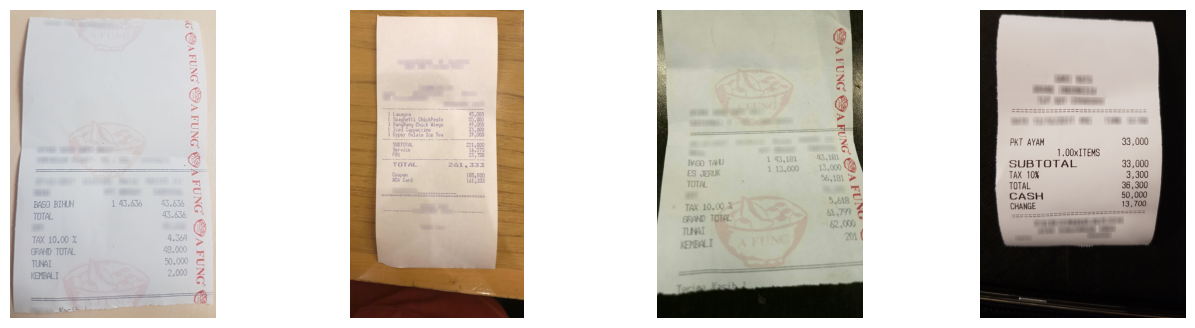

In [158]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for i, image in enumerate(ds_train[4:8]['image']):
    axs[i].imshow(image)
    axs[i].set_axis_off()

plt.show()

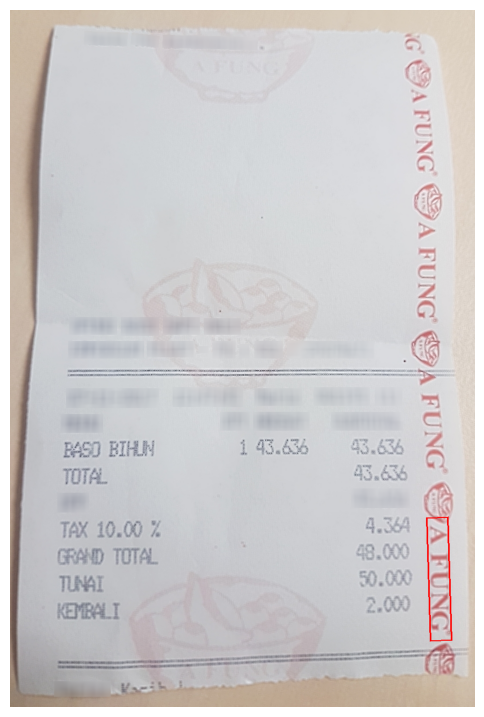

In [159]:
sample = ds_train[4]['image']
draw = ImageDraw.Draw(sample)

dots = [
    (773, 944), (814, 942),
    (821, 1172), (780,1174)
]

draw.polygon(dots, outline='red', width=3)

plt.figure(figsize=(6,10))
plt.imshow(sample)
plt.axis('off')
plt.show()

In [160]:
for i in inputs:
    info = extract_info(i['separated_lines'])
    details = classify_info(info)

    i['details'] = details

In [161]:
ocr = PaddleOCR(
    ocr_version="PP-OCRv3",
    use_textline_orientation=True,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    lang='en'
)

for input in inputs:
    print(f'processing {input['name']}')

    res = ocr.predict(input=enhance_contrast(input['img']),
                    #   text_det_unclip_ratio=1.1,
                    #   text_det_box_thresh=0.5
                    )

    if input['save_file']:
        for r in res:
            r.save_to_img(f"./out/paddle/test/{input['name']}")
            r.save_to_json(f"./out/paddle/test/{input['name']}")

    boxes_items = group_paddle_result(res)
    lines = group_boxes_geometric(boxes_items)

    print(f"\nLines:")
    for l in lines:
        print(l)

    info = extract_info(lines=lines)
    classified = classify_info(info=info)

    score = evaluate_details(gt_details=input['details'], ocr_details=classified)

    print('\n--------------------------')
    print(f'Score: {score}')
    print('--------------------------\n')

    print(f"\nDetails:")
    for c in classified:
        print(c)

    print('------------------------\n')
    print('==================================\n\n\n')

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/michaelyusaktarigan/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv3_mobile_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/michaelyusaktarigan/.paddlex/official_models/PP-OCRv3_mobile_det`.
Creating model: ('en_PP-OCRv3_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/michaelyusaktarigan/.paddlex/official_models/en_PP-OCRv3_mobile_rec`.


processing input 1


There is not input file name as reference for name of saved result file. So the saved result file would be named with timestamp and random number: `1757608734_3133`.



Lines:
['Bintang Bremer', '1', '59,000']
['Chicken H-H', '190.000']
['Ades', '1', '10.000']
['Sub Totai', '259,000']
['Service', '9,600']
['Tax', '52,416']
['Discount', '19,000']
['TOTAL', '302,016']

--------------------------
Score: 1.0
--------------------------


Details:
{'category': 'item', 'info': {'item': 'Bintang Bremer', 'qty': 1, 'price': {'currency': None, 'numeric': 59000.0}}}
{'category': 'item', 'info': {'item': 'Chicken H-H', 'qty': 1, 'price': {'currency': None, 'numeric': 190000.0}}}
{'category': 'item', 'info': {'item': 'Ades', 'qty': 1, 'price': {'currency': None, 'numeric': 10000.0}}}
{'category': 'summary', 'info': {'item': 'sub total', 'price': {'currency': None, 'numeric': 259000.0}}}
{'category': 'summary', 'info': {'item': 'service', 'price': {'currency': None, 'numeric': 9600.0}}}
{'category': 'summary', 'info': {'item': 'tax', 'price': {'currency': None, 'numeric': 52416.0}}}
{'category': 'summary', 'info': {'item': 'discount', 'price': {'currency': None, '

There is not input file name as reference for name of saved result file. So the saved result file would be named with timestamp and random number: `1757608735_2786`.
Resized image size (4096x2304) exceeds max_side_limit of 4000. Resizing to fit within limit.



Lines:
['PASO BIHUN', '143.636', '43.636']
['TOTAL', '43.636']
['TAX 10.00%', '4.364']
['GRAND TOTAL', '48.000']
['TUNAI', '50.000']
['KEMBALI', '2.000']

--------------------------
Score: 0.8
--------------------------


Details:
{'category': 'item', 'info': {'item': 'PASO BIHUN', 'qty': 1, 'price': {'currency': None, 'numeric': 43636.0}}}
{'category': 'summary', 'info': {'item': 'total', 'price': {'currency': None, 'numeric': 43636.0}}}
{'category': 'summary', 'info': {'item': 'grand total', 'price': {'currency': None, 'numeric': 48000.0}}}
{'category': 'summary', 'info': {'item': 'tunai', 'price': {'currency': None, 'numeric': 50000.0}}}
{'category': 'summary', 'info': {'item': 'kembali', 'price': {'currency': None, 'numeric': 2000.0}}}
------------------------




processing input 3


There is not input file name as reference for name of saved result file. So the saved result file would be named with timestamp and random number: `1757608740_3397`.



Lines:
['1.Lasanna', '000']
['1 Spaghetti ChickPesto']
['1 BangBang Chick Wings']
['1 Iced Cappuccino']
['1 Gypsy Gelalo Ice Tea']
['SUDTOTAL']
['Service']
['9T', '575']
['758']
['261333']
['100,000']
['BCA Card']
['161,333']

--------------------------
Score: 0.0
--------------------------


Details:
{'category': 'item', 'info': {'item': '1 Spaghetti ChickPesto', 'qty': 1, 'price': {'currency': None, 'numeric': 0}}}
{'category': 'item', 'info': {'item': '1 BangBang Chick Wings', 'qty': 1, 'price': {'currency': None, 'numeric': 0}}}
{'category': 'item', 'info': {'item': '1 Iced Cappuccino', 'qty': 1, 'price': {'currency': None, 'numeric': 0}}}
{'category': 'item', 'info': {'item': '1 Gypsy Gelalo Ice Tea', 'qty': 1, 'price': {'currency': None, 'numeric': 0}}}
{'category': 'summary', 'info': {'item': 'subtotal', 'price': {'currency': None, 'numeric': 0}}}
{'category': 'summary', 'info': {'item': 'service', 'price': {'currency': None, 'numeric': 0}}}
{'category': 'item', 'info': {'item'